In [5]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import kpss, adfuller
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL

In [6]:
def autocovariance(series, lag):
    n = len(series)
    mean = np.mean(series)
    return np.sum((series[lag:] - mean) * (series[:n - lag] - mean)) / n

def autocorrelation(series, lag):
    return autocovariance(series, lag) / autocovariance(series, 0)

In [7]:
def analisar_estacionariedade(serie_raw, col, titulo, max_lag=20):
    """
    Recebe um DataFrame (serie_raw) e o nome da coluna numérica (col).
    Plota a série, ACF e exibe os resultados de ADF e KPSS.
    """
    valores = serie_raw[col].dropna().values

    # Plot da série, ACF e PACF
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
    axes[0].plot(valores)
    axes[0].set_title(titulo + ' - Série')
    axes[0].set_xlabel('tempo')
    axes[0].set_ylabel('valor')
    plot_acf(valores, lags=max_lag, ax=axes[1], title=titulo + ' - ACF')
    plot_pacf(valores, lags=max_lag, ax=axes[2], title=titulo + ' - PACF')
    plt.tight_layout()
    plt.show()

    sep = '=' * 55

    # ADF
    adf_res = adfuller(valores)
    print('\n' + sep)
    print('  ' + titulo)
    print(sep)
    print('\n[ADF - H0: série NÃO é estacionária]')
    print('  Estatística ADF : ' + str(round(adf_res[0], 4)))
    print('  p-valor         : ' + str(round(adf_res[1], 4)))
    print('  Valores Críticos:')
    for chave, valor in adf_res[4].items():
        print('    ' + chave + ': ' + str(round(valor, 4)))
    adf_estac = adf_res[1] < 0.05
    sinal_adf = '< 0.05' if adf_estac else '>= 0.05'
    concl_adf = 'ESTACIONÁRIA' if adf_estac else 'NÃO ESTACIONÁRIA'
    print('  → Conclusão ADF: ' + concl_adf + ' (p ' + sinal_adf + ')')

    # KPSS
    kpss_res = kpss(valores, regression='c')
    print('\n[KPSS - H0: série É estacionária]')
    print('  Estatística KPSS: ' + str(round(kpss_res[0], 4)))
    print('  p-valor         : ' + str(round(kpss_res[1], 4)))
    print('  Valores Críticos:')
    for chave, valor in kpss_res[3].items():
        print('    ' + chave + ': ' + str(round(valor, 4)))
    kpss_estac = kpss_res[1] >= 0.05
    sinal_kpss = '>= 0.05' if kpss_estac else '< 0.05'
    concl_kpss = 'ESTACIONÁRIA' if kpss_estac else 'NÃO ESTACIONÁRIA'
    print('  → Conclusão KPSS: ' + concl_kpss + ' (p ' + sinal_kpss + ')')

    # Veredicto
    print('\n[VEREDICTO FINAL]')
    if adf_estac and kpss_estac:
        veredicto = 'ESTACIONÁRIA (ambos os testes concordam)'
    elif not adf_estac and not kpss_estac:
        veredicto = 'NÃO ESTACIONÁRIA (ambos os testes concordam)'
    elif adf_estac and not kpss_estac:
        veredicto = 'INCONCLUSIVO - possível diferença estacionária (DS)'
    else:
        veredicto = 'INCONCLUSIVO - possível estacionariedade em torno de tendência (TS)'
    print('  ' + veredicto + '\n')
    return {'adf_pval': adf_res[1], 'kpss_pval': kpss_res[1],
            'adf_estac': adf_estac, 'kpss_estac': kpss_estac, 'veredicto': veredicto}

In [8]:
df = pd.read_excel('serie_sarima.xlsx')
df.head()

,Data,y
0,2022-01-01,24.219961
1,2022-01-02,21.483120
2,2022-01-03,21.846712
3,2022-01-04,20.196590
4,2022-01-05,19.661745


In [9]:
# renomear colunas 
df.columns = ['data', 'valor']
df.head()

,data,valor
0,2022-01-01,24.219961
1,2022-01-02,21.483120
2,2022-01-03,21.846712
3,2022-01-04,20.196590
4,2022-01-05,19.661745


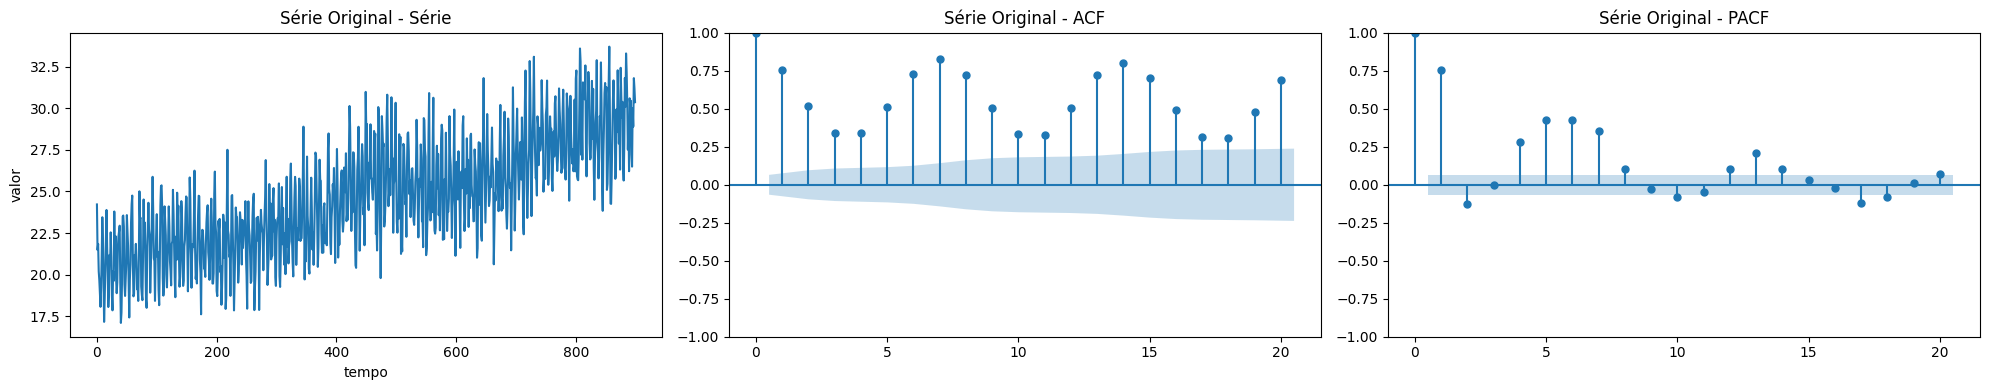


  Série Original

[ADF - H0: série NÃO é estacionária]
  Estatística ADF : -0.4636
  p-valor         : 0.8989
  Valores Críticos:
    1%: -3.4378
    5%: -2.8648
    10%: -2.5685
  → Conclusão ADF: NÃO ESTACIONÁRIA (p >= 0.05)

[KPSS - H0: série É estacionária]
  Estatística KPSS: 5.3475
  p-valor         : 0.01
  Valores Críticos:
    10%: 0.347
    5%: 0.463
    2.5%: 0.574
    1%: 0.739
  → Conclusão KPSS: NÃO ESTACIONÁRIA (p < 0.05)

[VEREDICTO FINAL]
  NÃO ESTACIONÁRIA (ambos os testes concordam)



{'adf_pval': np.float64(0.8989325523414302),
 'kpss_pval': np.float64(0.01),
 'adf_estac': np.False_,
 'kpss_estac': np.False_,
 'veredicto': 'NÃO ESTACIONÁRIA (ambos os testes concordam)'}

In [10]:
analisar_estacionariedade(df, 'valor', 'Série Original')

quando m = 2: 


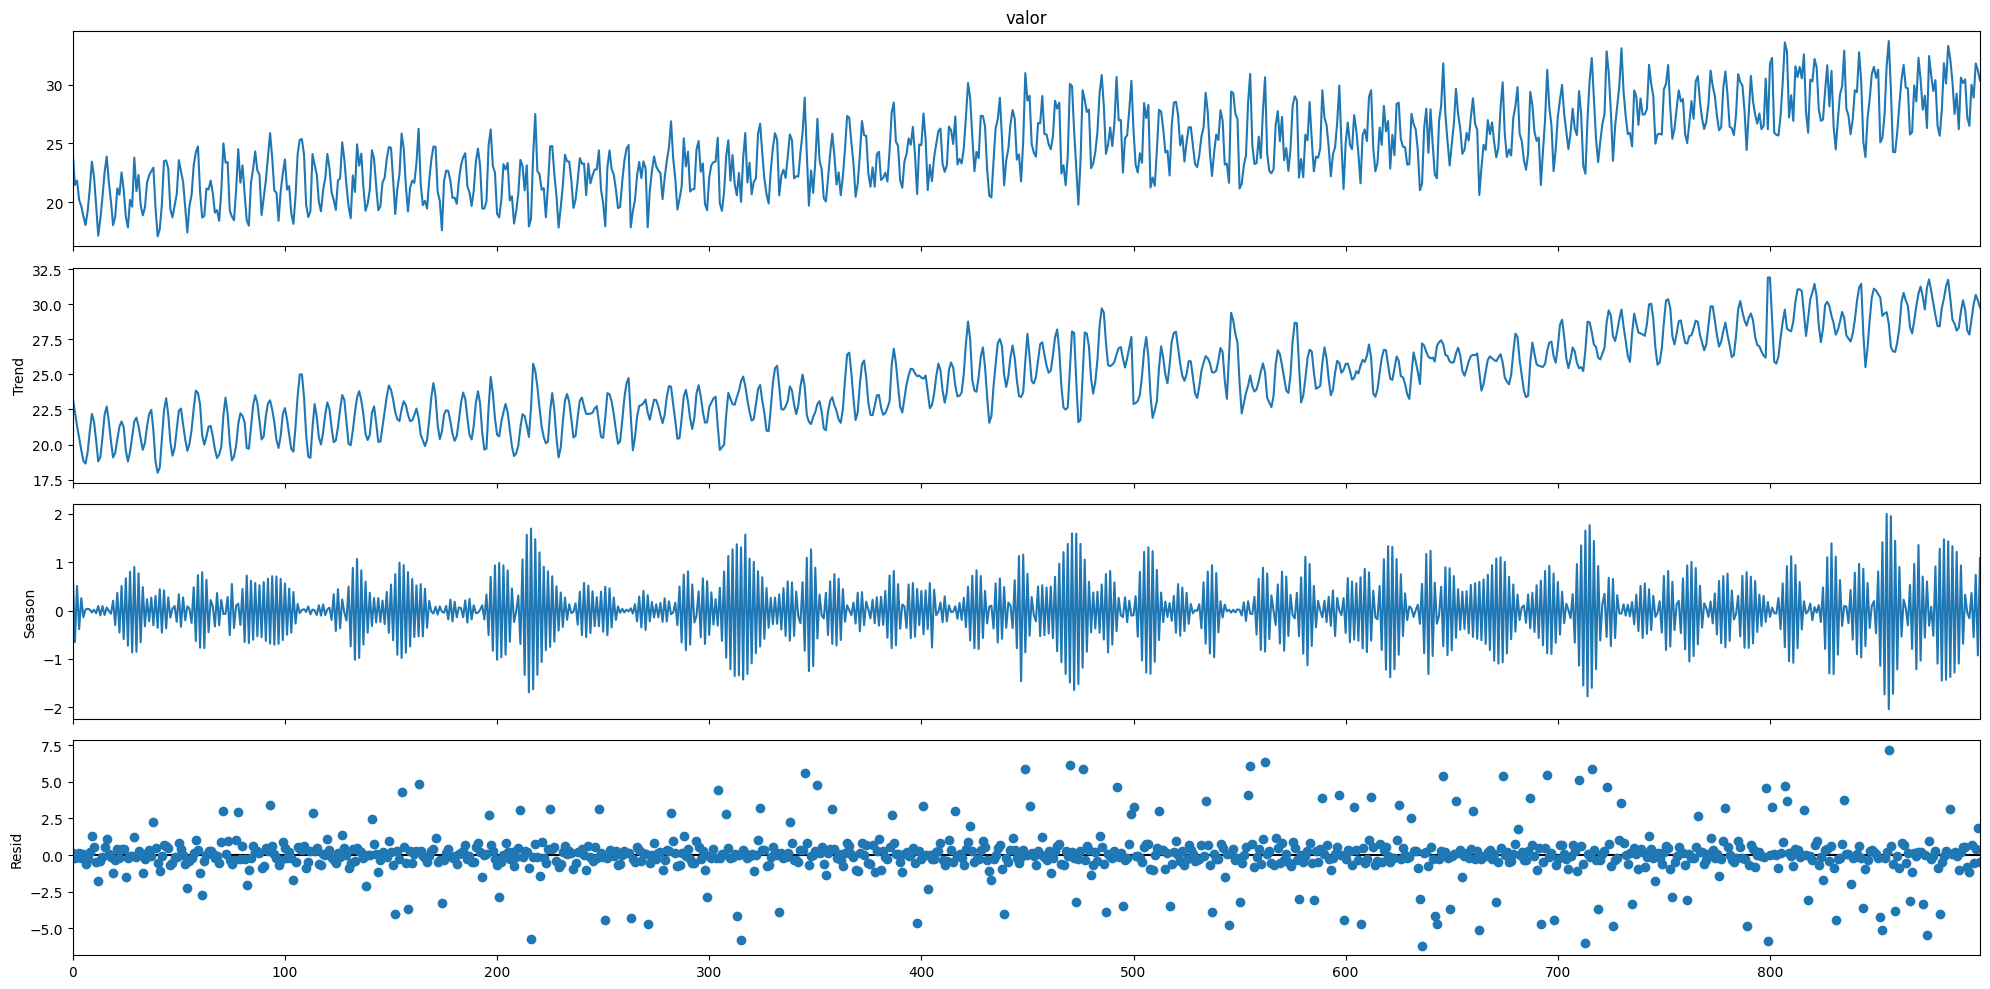

quando m = 7:


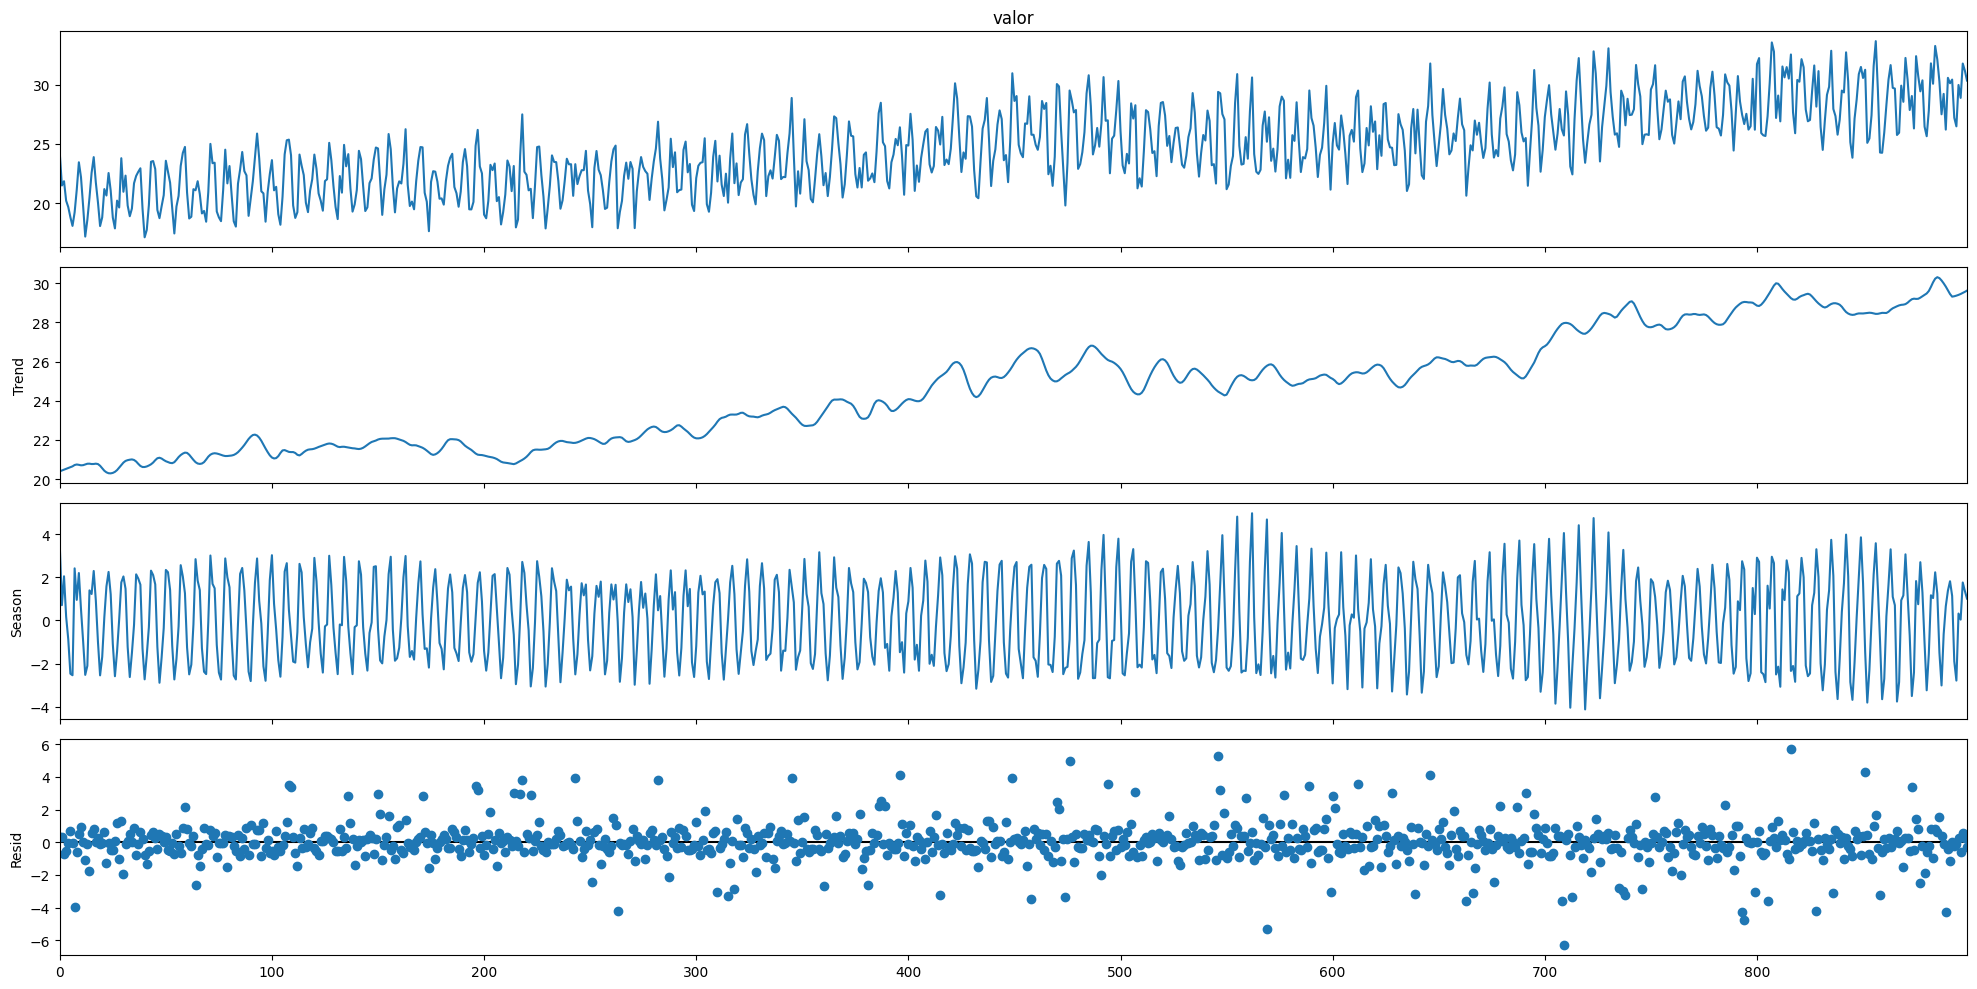

In [21]:
print("quando m = 2: ") 

m = 2
stl = STL(df['valor'], period=m, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(20,10)
plt.tight_layout()
plt.show()

print("quando m = 7:")
m = 7
stl = STL(df['valor'], period=m, robust=True).fit()
fig = stl.plot()
fig.set_size_inches(20,10)
plt.tight_layout()
plt.show()

In [ ]:
forca_sazonalidade = 1 - (np.var(stl.resid) / np.var(df['valor']))

In [ ]:
h = 3
train = df['valor'].iloc[:-h]
test = df['valor'].iloc[-h:]

In [ ]:
# variaveis auxiliares
melhor_bic = float("inf")
melhor_ordem = None
melhor_modelo = None

for p in range(0,5):
    for d in range(0,3):
        for q in range(0,5):
            if p == 0 and d == 0 and q == 0:
                continue
            modelo = ARIMA(train, order=(p,d,q)).fit()
            bic_for = float(modelo.bic)
            
            if melhor_ordem is None: 
                melhor_bic = bic_for
                melhor_ordem = (p,d,q)
                melhor_modelo = modelo
            else:
                if bic_for < melhor_bic:
                    melhor_bic = bic_for
                    melhor_ordem = (p,d,q)
                    melhor_modelo = modelo
                

print(f"Melhor ARIMA {melhor_ordem} com BIC {melhor_bic:.2f}")

Melhor ARIMA (0, 1, 3) com BIC 1715.06


Ljung box lags:20
      lb_stat  lb_pvalue
20  13.984023   0.831305


<Figure size 0x400 with 0 Axes>

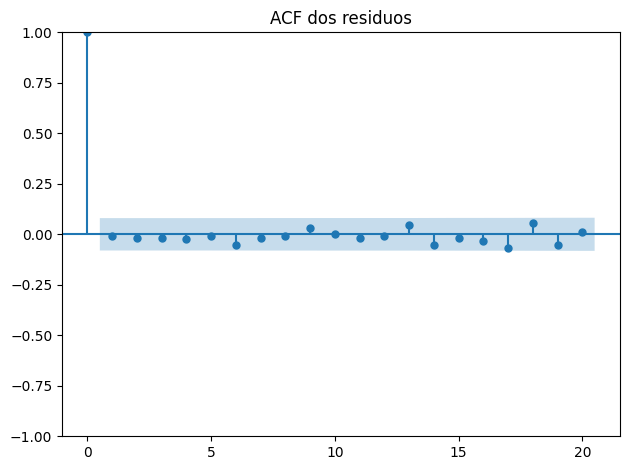

In [ ]:
res = melhor_modelo.resid

lb = acorr_ljungbox(res, lags=[20])
print("Ljung box lags:20")
print(lb)

plt.figure(figsize=(0,4))
plot_acf(res, lags=20)
plt.title("ACF dos residuos")
plt.tight_layout()
plt.show()
